IMDB Dataset Loaded Successfully
Training Samples : 25000
Testing Samples : 25000

Padding Completed
Shape of x_train : (25000, 256)
Shape of x_test : (25000, 256)

Model Summary


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 256, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,137 (2.58 MB)

 Trainable params: 675,137 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 99ms/step - accuracy: 0.7629 - loss: 0.4800 - val_accuracy: 0.8566 - val_loss: 0.3486
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 89ms/step - accuracy: 0.8955 - loss: 0.2703 - val_accuracy: 0.8746 - val_loss: 0.3025
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 89ms/step - accuracy: 0.9174 - loss: 0.2227 - val_accuracy: 0.8672 - val_loss: 0.4236
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 86ms/step - accuracy: 0.9441 - loss: 0.1561 - val_accuracy: 0.8586 - val_loss: 0.3815
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 86ms/step - accuracy: 0.9571 - loss: 0.1210 - val_accuracy: 0.8598 - val_loss: 0.4183


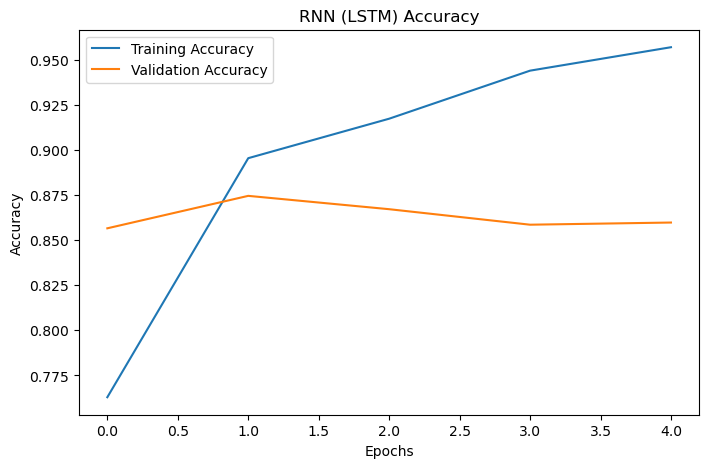

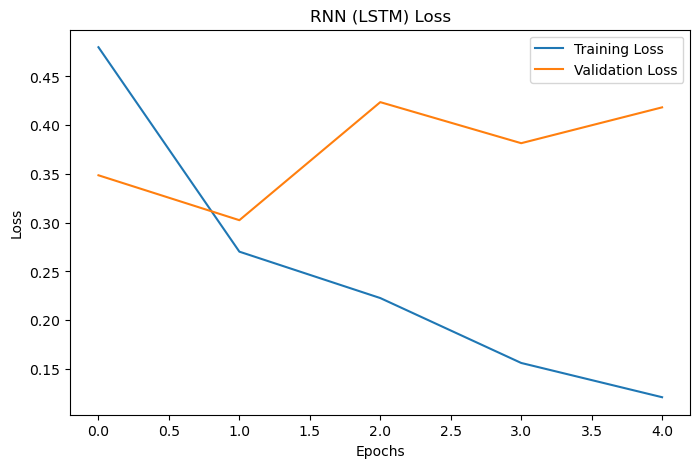

782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.8570 - loss: 0.4382

Test Accuracy : 0.8569999933242798
Test Loss : 0.43816080689430237
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step

Review : This movie was very good and interesting
Sentiment : Positive 😊
Prediction Score : 0.84250027


In [6]:
# ---------------------------------------------------------
# SENTIMENT ANALYSIS USING RNN (LSTM)
# IMDB DATASET + VISUALIZATION
# ---------------------------------------------------------

# -----------------------------
# Step 1 : Import Libraries
# -----------------------------

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.datasets import imdb
from tensorflow.keras.optimizers import Adam


# ---------------------------------------------------------
# Step 2 : Load IMDB Dataset
# ---------------------------------------------------------

# Vocabulary size
num_words = 10000

# Maximum review length
max_length = 256

# Load dataset
(x_train, y_train), (x_test, y_test) = imdb.load_data(
    num_words=num_words
)

print("IMDB Dataset Loaded Successfully")
print("Training Samples :", len(x_train))
print("Testing Samples :", len(x_test))


# ---------------------------------------------------------
# Step 3 : Padding Sequences
# ---------------------------------------------------------

# Make all reviews same length
x_train = pad_sequences(
    x_train,
    maxlen=max_length
)

x_test = pad_sequences(
    x_test,
    maxlen=max_length
)

print("\nPadding Completed")
print("Shape of x_train :", x_train.shape)
print("Shape of x_test :", x_test.shape)


# ---------------------------------------------------------
# Step 4 : Hyperparameters
# ---------------------------------------------------------

embedding_size = 64
rnn_units = 64
dropout_rate = 0.5
learning_rate = 0.001
epochs = 5
batch_size = 64


# ---------------------------------------------------------
# Step 5 : Build RNN Model
# ---------------------------------------------------------

model = Sequential()

# Embedding Layer
model.add(
    Embedding(
        input_dim=num_words,
        output_dim=embedding_size,
        input_length=max_length
    )
)

# LSTM Layer
model.add(
    LSTM(
        rnn_units
    )
)

# Dropout Layer
model.add(
    Dropout(
        dropout_rate
    )
)

# Dense Hidden Layer
model.add(
    Dense(
        32,
        activation='relu'
    )
)

# Output Layer
model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

# Build model manually
model.build(
    input_shape=(None, max_length)
)


# ---------------------------------------------------------
# Step 6 : Compile Model
# ---------------------------------------------------------

optimizer = Adam(
    learning_rate=learning_rate
)

model.compile(
    loss='binary_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)


# ---------------------------------------------------------
# Step 7 : Model Summary
# ---------------------------------------------------------

print("\nModel Summary")
model.summary()


# ---------------------------------------------------------
# Step 8 : Train Model
# ---------------------------------------------------------

history = model.fit(
    x_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2
)


# ---------------------------------------------------------
# Step 9 : Accuracy Graph
# ---------------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("RNN (LSTM) Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()


# ---------------------------------------------------------
# Step 10 : Loss Graph
# ---------------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title("RNN (LSTM) Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()


# ---------------------------------------------------------
# Step 11 : Evaluate Model
# ---------------------------------------------------------

loss, accuracy = model.evaluate(
    x_test,
    y_test
)

print("\nTest Accuracy :", accuracy)
print("Test Loss :", loss)


# ---------------------------------------------------------
# Step 12 : Prediction Example
# ---------------------------------------------------------

# Load word dictionary
word_index = imdb.get_word_index()


# Function to preprocess custom review
def preprocess_text(text):

    # Convert to lowercase
    words = text.lower().split()

    # Convert words to integers
    encoded = [
        word_index.get(word, 0)
        for word in words
    ]

    # Padding
    padded = pad_sequences(
        [encoded],
        maxlen=max_length
    )

    return padded


# Custom Review
review = "This movie was very good and interesting"

# Preprocess review
processed_review = preprocess_text(review)

# Prediction
prediction = model.predict(processed_review)

print("\nReview :", review)

# Sentiment Result
if prediction[0][0] > 0.5:
    print("Sentiment : Positive 😊")
else:
    print("Sentiment : Negative 😞")

# Show prediction probability
print("Prediction Score :", prediction[0][0])